In [47]:
SIM_FILE = '/datascope/subaru/user/swei20/data/bosz50000/z1/mag205_225_lowT_1M/train_200k_0/dataset.h5'
DENOISED_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000_v3ep190/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0_v3ep190_N50000.npz'
DENOISED_MASK = '/datascope/subaru/user/swei20/model/bosz50000_mask.npy'

N = 10000
TRAIN_NOISE_LEVEL = 0.001

# PARAM = 'T_eff'
# PARAM_LATEX = R"$T_{\mathrm{eff}}$"
# DENOISED_PARAM = 'teff'

PARAM = 'log_g'
PARAM_LATEX = R"$\log g$"
DENOISED_PARAM = 'logg'

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

# Load the training data

In [49]:
# Load the pandas DataFrame from the HDF5 file stored in /dataset/params/table
with h5py.File(SIM_FILE, 'r') as f:
    params = pd.read_hdf(SIM_FILE, key='dataset/params')

params.shape

(200000, 35)

In [50]:
for c in params.columns:
    print(c, params[c].dtype, params[c].nunique())

id int64 200000
redshift float64 200000
redshift_err float64 1
exp_count int64 1
exp_time float64 1
seeing float64 200000
ext float64 0
target_zenith_angle float64 200000
target_field_angle float64 200000
moon_zenith_angle float64 200000
moon_target_angle float64 200000
moon_phase float64 1
snr float64 200000
mag float64 200000
fiberid float64 0
cont_fit float64 0
random_seed float64 0
Fe_H float64 0
Fe_H_err float64 0
M_H float64 40185
M_H_err float64 0
a_M float64 40104
a_M_err float64 0
C_M float64 40021
C_M_err float64 0
O_M float64 0
O_M_err float64 0
T_eff float64 40241
T_eff_err float64 0
log_g float64 39492
log_g_err float64 0
N_He float64 0
v_turb float64 0
L_H float64 0
interp_param object 5


In [51]:
params[:N]

,id,redshift,redshift_err,exp_count,exp_time,seeing,ext,target_zenith_angle,target_field_angle,moon_zenith_angle,...,O_M,O_M_err,T_eff,T_eff_err,log_g,log_g_err,N_He,v_turb,L_H,interp_param
0,0,-0.000017,0.0,12,900.0,1.053979,NaN,44.917437,0.524771,71.249584,...,NaN,NaN,5500.000000,NaN,3.500000,NaN,NaN,NaN,NaN,C_M
1,1,-0.000021,0.0,12,900.0,1.258634,NaN,38.512811,0.516283,60.858768,...,NaN,NaN,5500.000000,NaN,1.000000,NaN,NaN,NaN,NaN,C_M
2,2,0.000827,0.0,12,900.0,1.383423,NaN,30.961085,0.419070,52.893598,...,NaN,NaN,5250.000000,NaN,2.000000,NaN,NaN,NaN,NaN,M_H
3,3,0.000869,0.0,12,900.0,1.426675,NaN,0.540493,0.057501,66.211551,...,NaN,NaN,4000.000000,NaN,3.204733,NaN,NaN,NaN,NaN,log_g
4,4,0.000995,0.0,12,900.0,1.054560,NaN,17.375216,0.046250,56.400409,...,NaN,NaN,4140.409628,NaN,2.500000,NaN,NaN,NaN,NaN,T_eff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,-0.000004,0.0,12,900.0,1.343521,NaN,31.438738,0.507782,35.352921,...,NaN,NaN,5000.000000,NaN,3.500000,NaN,NaN,NaN,NaN,a_M
9996,9996,-0.000208,0.0,12,900.0,1.461635,NaN,11.084327,0.515153,73.686910,...,NaN,NaN,5250.000000,NaN,2.500000,NaN,NaN,NaN,NaN,a_M
9997,9997,-0.000609,0.0,12,900.0,0.865536,NaN,10.878349,0.306677,71.573519,...,NaN,NaN,5250.000000,NaN,2.000000,NaN,NaN,NaN,NaN,M_H
9998,9998,-0.000650,0.0,12,900.0,1.221635,NaN,25.134942,0.050104,68.718483,...,NaN,NaN,6000.000000,NaN,1.358931,NaN,NaN,NaN,NaN,log_g


In [52]:
# Select only those spectra that were interpolated in the log g direction
data_mask = params['interp_param'] == PARAM
data_idx = np.where(data_mask)[0]

data_mask.sum()

39483

In [53]:
# Load the selected spectra from the HDF5 file
with h5py.File(SIM_FILE, 'r') as f:
    wave = f['spectrumdataset/wave'][:]
    flux = f['dataset/arrays/flux/value'][data_idx[:N], :]
    flux_err = f['dataset/arrays/error/value'][data_idx[:N], :]

wave.shape, flux.shape, flux_err.shape

((4096,), (10000, 4096), (10000, 4096))

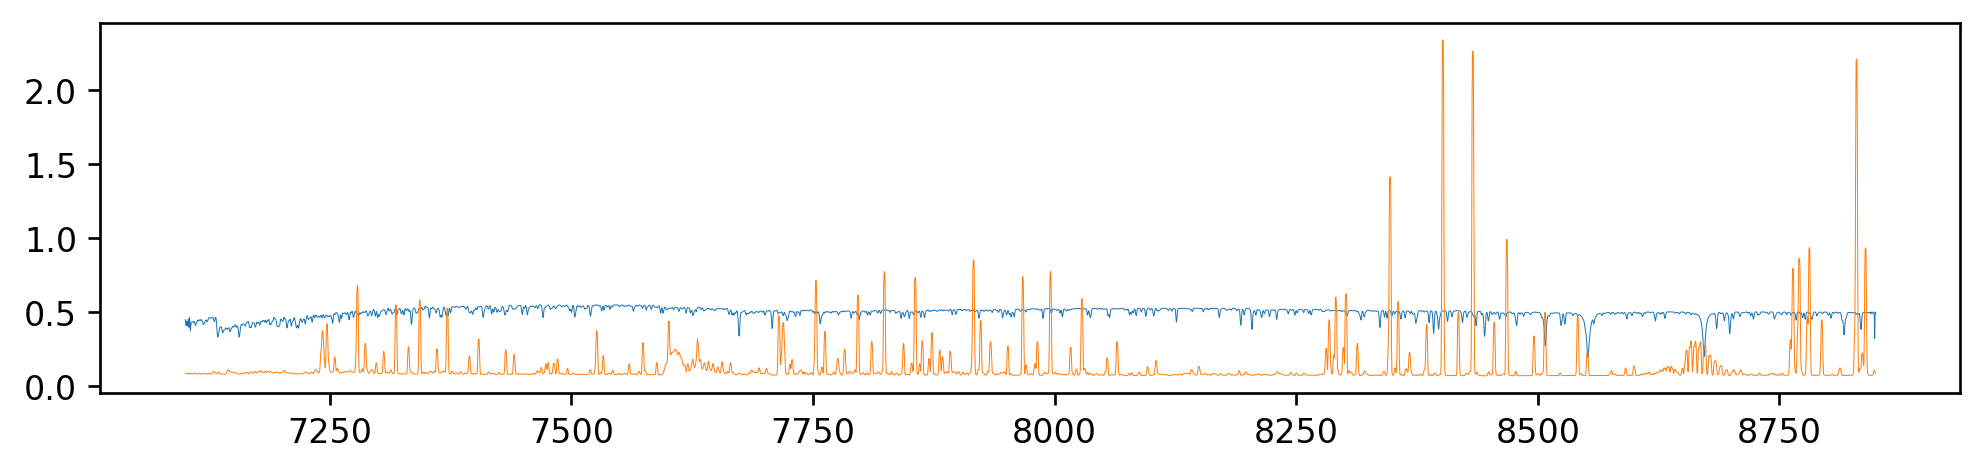

In [54]:
i = 0

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)
ax.plot(wave, flux[i, :], lw=0.3)
ax.plot(wave, flux_err[i, :], lw=0.3)

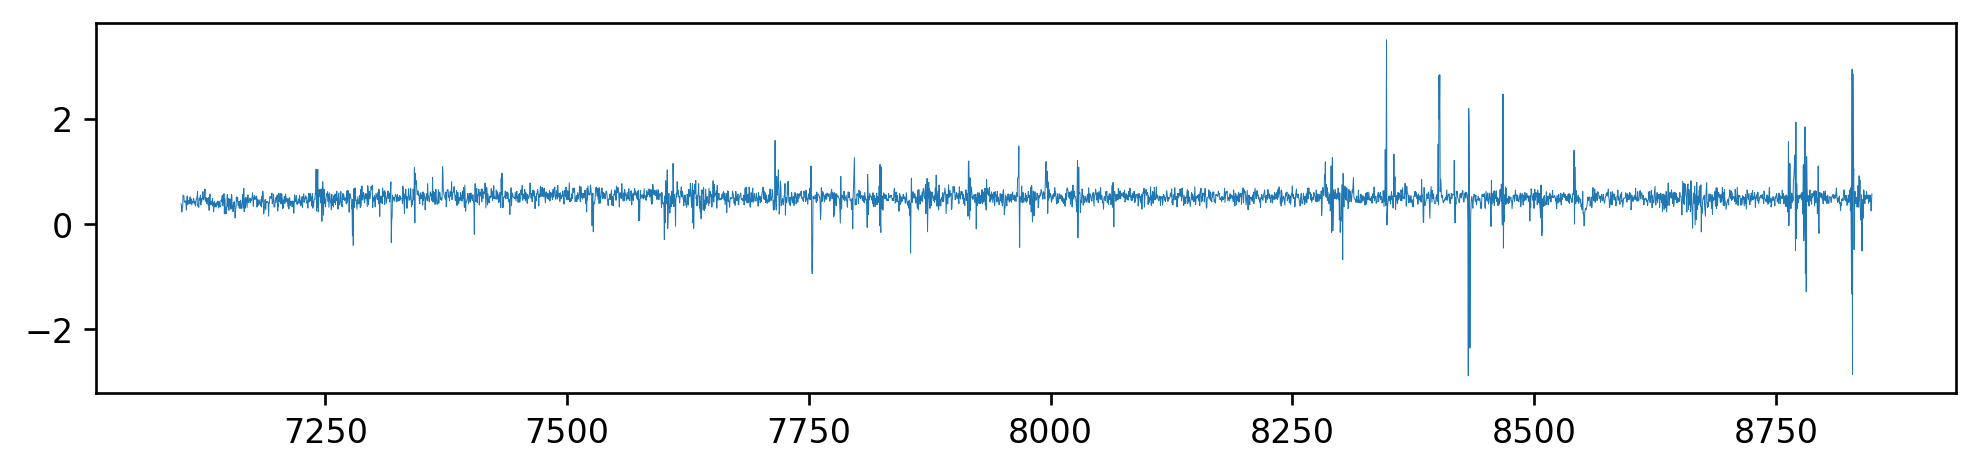

In [55]:
fig, ax = plt.subplots(figsize=(10, 2), dpi=240)
ax.plot(wave, flux[i, :] + np.random.normal(loc=0.0, scale=flux_err[i, :], size=flux.shape[1]), lw=0.3)

# Load the denoised data

In [56]:
wave_mask = np.load(DENOISED_MASK)
wave_mask.shape, wave_mask.sum()

((4096,), 3481)

In [57]:
denoised = np.load(DENOISED_FILE)
list(denoised.keys())

['wave',
 'flux',
 'noisy',
 'flux_err',
 'denoised',
 'rv',
 'teff',
 'logg',
 'mh',
 'snr0',
 'snr00',
 'snr_noisy_db',
 'snr_denoised_db',
 'nl',
 'ckpt',
 'config',
 'mask_path',
 'source_npz']

In [58]:
denoised['wave'].shape, denoised['flux'].shape

((3481,), (50000, 3481))

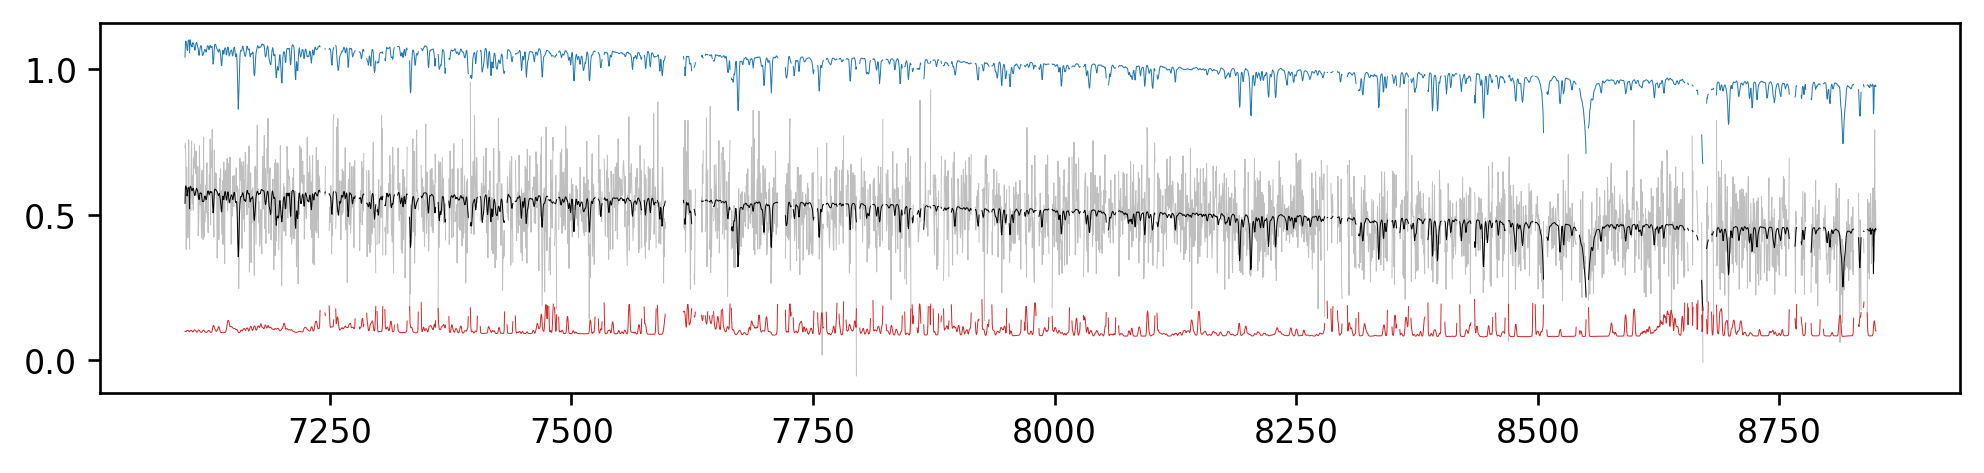

In [59]:
i = 0

w = wave
f = np.full_like(wave, np.nan)

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = denoised['noisy'][i, :]
ax.plot(wave, f, lw=0.3, c='gray', alpha=0.5)

f[wave_mask] = denoised['flux'][i, :]
ax.plot(wave, f, lw=0.3, c='k')

f[wave_mask] = denoised['denoised'][i, :]
ax.plot(wave, f + 0.5, lw=0.3, c='tab:blue')

f[wave_mask] = denoised['flux_err'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:red')

# Train the downstream parameter estimator

### Add noise to the training data

In [60]:
# Target: log g aligned to the loaded spectra subset
y = params[PARAM].to_numpy()[data_idx[:N]]

# Noisy flux
err = flux_err
mask = np.isfinite(err)
print((~mask).any(axis=1).sum(), "spectra have non-finite error values")

mean_err = np.nanmean(err, axis=1)  # Replace non-finite values with median
err = np.where(mask, err, mean_err[:, None])
print((~mask).any(axis=1).sum(), "spectra have non-finite error values")

10000 spectra have non-finite error values
10000 spectra have non-finite error values


In [61]:
rng = np.random.default_rng(42)
x = flux[:, wave_mask] + TRAIN_NOISE_LEVEL * rng.normal(loc=0.0, scale=err[:, wave_mask], size=flux[:, wave_mask].shape)

In [62]:
x.shape, y.shape

((10000, 3481), (10000,))

(array([211., 185., 194., 209., 216., 188., 201., 182., 201., 216., 228.,
        203., 209., 191., 194., 219., 213., 174., 204., 203., 189., 197.,
        194., 202., 201., 184., 202., 193., 214., 200., 210., 189., 222.,
        184., 203., 189., 211., 207., 209., 171., 190., 198., 209., 204.,
        216., 205., 190., 197., 188., 191.]),
 array([1.00022154, 1.08020717, 1.16019281, 1.24017844, 1.32016407,
        1.4001497 , 1.48013533, 1.56012096, 1.64010659, 1.72009222,
        1.80007786, 1.88006349, 1.96004912, 2.04003475, 2.12002038,
        2.20000601, 2.27999164, 2.35997727, 2.43996291, 2.51994854,
        2.59993417, 2.6799198 , 2.75990543, 2.83989106, 2.91987669,
        2.99986233, 3.07984796, 3.15983359, 3.23981922, 3.31980485,
        3.39979048, 3.47977611, 3.55976174, 3.63974738, 3.71973301,
        3.79971864, 3.87970427, 3.9596899 , 4.03967553, 4.11966116,
        4.1996468 , 4.27963243, 4.35961806, 4.43960369, 4.51958932,
        4.59957495, 4.67956058, 4.75954621, 4.

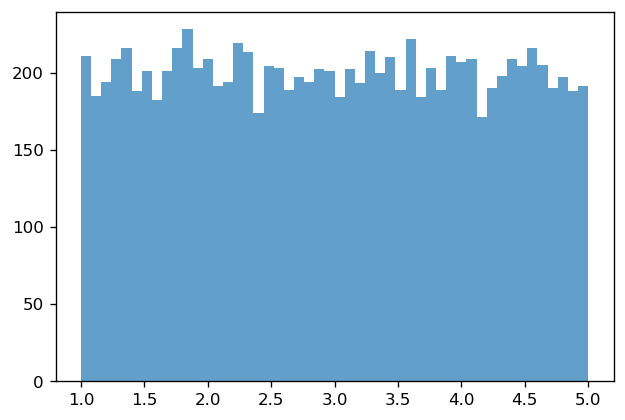

In [63]:
# Plot the histogram of the target values
plt.figure(figsize=(6, 4), dpi=120)
plt.hist(y, bins=50, alpha=0.7)

### Train/test split

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [65]:
print(np.isfinite(err).all(), np.isfinite(x).all(), np.isfinite(y).all())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

True True True
(8000, 3481) (2000, 3481) (8000,) (2000,)


### Train a RF

In [66]:
# # Random forest regressor
# rf = RandomForestRegressor(
#     n_estimators=1000,
#     random_state=42,
#     n_jobs=-1
# )
# rf.fit(X_train, y_train)

# # Evaluate
# y_pred = rf.predict(X_test)
# mae = mean_absolute_error(y_test, y_pred)
# rmse = mean_squared_error(y_test, y_pred, squared=False)
# r2 = r2_score(y_test, y_pred)

# print(f"MAE : {mae:.4f}")
# print(f"RMSE: {rmse:.4f}")
# print(f"R^2 : {r2:.4f}")

In [67]:
# plt.plot(y_test, y_pred, 'o', alpha=0.5)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

### Run PCA

In [68]:
from sklearn.decomposition import PCA

# PCA on x, keep first 100 principal components
pca = PCA(n_components=200, svd_solver="randomized", random_state=42)
x_pca = pca.fit_transform(x)

# Train/test split on PCA features
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    x_pca, y, test_size=0.2, random_state=42
)

X_train_pca.shape, X_test_pca.shape, y_train_pca.shape, y_test_pca.shape

((8000, 200), (2000, 200), (8000,), (2000,))

### Train an RF on the PCs

In [69]:
# Random Forest on PCA features
rf_pca = RandomForestRegressor(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)
rf_pca.fit(X_train_pca, y_train_pca)

# Evaluate
y_pred_pca = rf_pca.predict(X_test_pca)
mae_pca = mean_absolute_error(y_test_pca, y_pred_pca)
rmse_pca = mean_squared_error(y_test_pca, y_pred_pca, squared=False)
r2_pca = r2_score(y_test_pca, y_pred_pca)

print(f"Explained variance (200 PCs): {pca.explained_variance_ratio_.sum():.4f}")
print(f"PCA+RF MAE : {mae_pca:.4f}")
print(f"PCA+RF RMSE: {rmse_pca:.4f}")
print(f"PCA+RF R^2 : {r2_pca:.4f}")

Explained variance (200 PCs): 0.9974
PCA+RF MAE : 0.3784
PCA+RF RMSE: 0.4965
PCA+RF R^2 : 0.8135


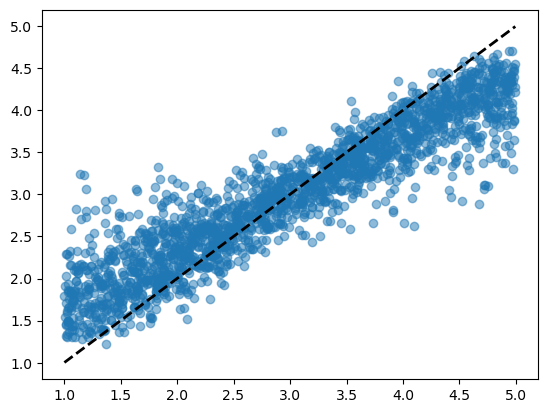

In [70]:
plt.plot(y_test_pca, y_pred_pca, 'o', alpha=0.5)
plt.plot([y_test_pca.min(), y_test_pca.max()], [y_test_pca.min(), y_test_pca.max()], 'k--', lw=2)

# Train LightGBM

In [71]:
import lightgbm as lgb

In [72]:
X_train_pca.shape, y_train_pca.shape

((8000, 200), (8000,))

In [73]:
# LightGBM on PCA features (reusing x_pca, X_train_pca, X_test_pca, y_train_pca, y_test_pca from previous cells)
lgb_model = lgb.LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.25,
    num_leaves=347,
    n_jobs=-1,
    random_state=42
)
lgb_model.fit(
    X_train_pca, y_train_pca,
    eval_set=[(X_test_pca, y_test_pca)],
)

# Evaluate
y_pred_lgb = lgb_model.predict(X_test_pca)
mae_lgb = mean_absolute_error(y_test_pca, y_pred_lgb)
rmse_lgb = mean_squared_error(y_test_pca, y_pred_lgb, squared=False)
r2_lgb = r2_score(y_test_pca, y_pred_lgb)

print(f"LGB+PCA MAE : {mae_lgb:.4f}")
print(f"LGB+PCA RMSE: {rmse_lgb:.4f}")
print(f"LGB+PCA R^2 : {r2_lgb:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018929 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 200
[LightGBM] [Info] Start training from score 2.995295
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

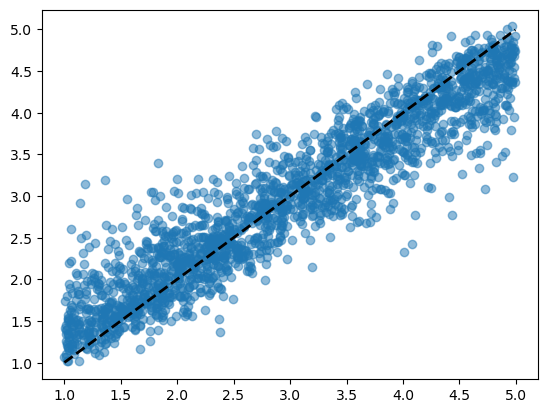

In [74]:
plt.plot(y_test_pca, y_pred_lgb, 'o', alpha=0.5)
plt.plot([y_test_pca.min(), y_test_pca.max()], [y_test_pca.min(), y_test_pca.max()], 'k--', lw=2)

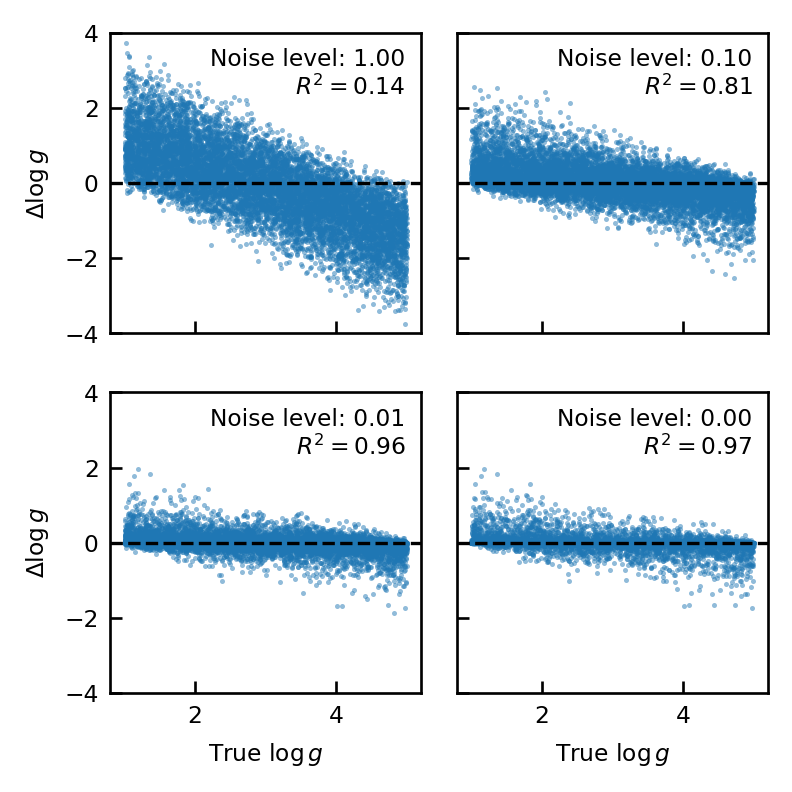

In [81]:
# Add all noise to the spectra

rng = np.random.default_rng(92)

fig, axes = plt.subplots(2, 2, figsize=(3.4, 3.4), dpi=240, sharex=True, sharey=True)

for i, (noise_level, ax) in enumerate(zip([1.0, 0.1, 0.01, 0.0], axes.flatten())):
    x_noisy = flux[:, wave_mask] + noise_level * rng.normal(loc=0.0, scale=err[:, wave_mask], size=flux[:, wave_mask].shape)

    # Predict log g using the trained LightGBM model on PCA features
    x_noisy_pca = pca.transform(x_noisy)
    y_pred_noisy = lgb_model.predict(x_noisy_pca)

    ax.plot(y, y_pred_noisy - y, '.', ms=1, alpha=0.5, rasterized=True)

    ax.text(0.95, 0.95,
            f"Noise level: {noise_level:.2f}\n$R^2 = {r2_score(y, y_pred_noisy):.2f}$",
            transform=ax.transAxes,
            fontsize=7,
            verticalalignment='top',
            horizontalalignment='right')

for ax in axes[-1, :]:
    ax.set_xlabel(R"True $\log g$", fontsize=7)

for ax in axes[:, 0]:
    ax.set_ylabel(R"$\Delta \log g$", fontsize=7)

for ax in axes.flatten():
    ax.set_ylim(-4, 4)
    ax.tick_params(axis='both', labelsize=7, direction='in')
    ax.axhline(0, color='k', linestyle='--', lw=1)

fig.tight_layout()
fig.savefig("../figs/fig_lightgbm.pdf")

# Apply the model to the test set

R^2 score for noisy predictions: 0.0473
R^2 score for denoised predictions: 0.2607


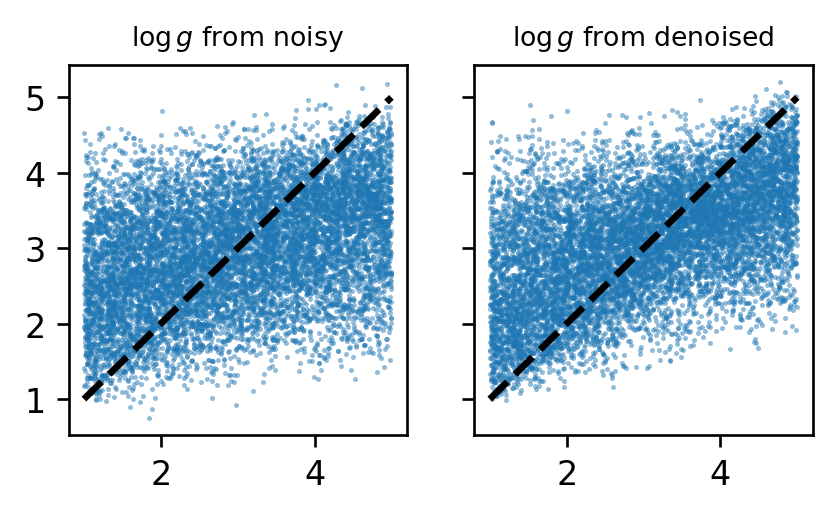

In [78]:
# Run through the noisy data and the denoised data

fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=240, sharex=True, sharey=True)

model_mask = denoised['snr00'] > 0
model_mask &= (denoised[DENOISED_PARAM] != np.round(denoised[DENOISED_PARAM], 1))

###### ####### #######

ax = axes[0]

x_noisy = denoised['noisy']

# Predict log g using the trained LightGBM model on PCA features
x_noisy_pca = pca.transform(x_noisy)
y_pred_noisy = lgb_model.predict(x_noisy_pca)

ax.plot(denoised[DENOISED_PARAM][model_mask], y_pred_noisy[model_mask], '.', ms=1, alpha=0.5)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)

ax.set_title(f"{PARAM_LATEX} from noisy", fontsize=8)

###### ####### #######

ax = axes[1]

x_denoised = denoised['denoised']

# Predict log g using the trained LightGBM model on PCA features
x_denoised_pca = pca.transform(x_denoised)
y_pred_denoised = lgb_model.predict(x_denoised_pca)

ax.plot(denoised[DENOISED_PARAM][model_mask], y_pred_denoised[model_mask], '.', ms=1, alpha=0.5)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)

ax.set_title(f"{PARAM_LATEX} from denoised", fontsize=8)

# Calculate the R^2 score for both noisy and denoised predictions
R_2 = r2_score(denoised[DENOISED_PARAM][model_mask], y_pred_noisy[model_mask])
print(f"R^2 score for noisy predictions: {R_2:.4f}")
R_2_denoised = r2_score(denoised[DENOISED_PARAM][model_mask], y_pred_denoised[model_mask])
print(f"R^2 score for denoised predictions: {R_2_denoised:.4f}")

R^2 score for noisy predictions: 0.2256
R^2 score for denoised predictions: 0.3921


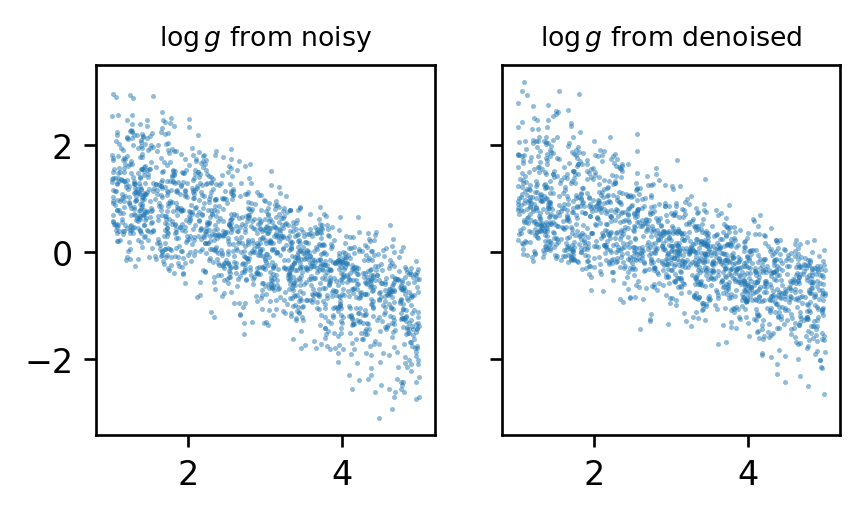

In [79]:
# Run through the noisy data and the denoised data

fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=240, sharex=True, sharey=True)

model_mask = denoised['snr00'] > 15
model_mask &= (denoised[DENOISED_PARAM] != np.round(denoised[DENOISED_PARAM], 1))

###### ####### #######

ax = axes[0]

x_noisy = denoised['noisy']

# Predict log g using the trained LightGBM model on PCA features
x_noisy_pca = pca.transform(x_noisy)
y_pred_noisy = lgb_model.predict(x_noisy_pca)

ax.plot(denoised[DENOISED_PARAM][model_mask], y_pred_noisy[model_mask] - denoised[DENOISED_PARAM][model_mask], '.', ms=1, alpha=0.5)
# ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)

ax.set_title(f"{PARAM_LATEX} from noisy", fontsize=8)

###### ####### #######

ax = axes[1]

x_denoised = denoised['denoised']

# Predict log g using the trained LightGBM model on PCA features
x_denoised_pca = pca.transform(x_denoised)
y_pred_denoised = lgb_model.predict(x_denoised_pca)

ax.plot(denoised[DENOISED_PARAM][model_mask], y_pred_denoised[model_mask] - denoised[DENOISED_PARAM][model_mask], '.', ms=1, alpha=0.5)
#ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)

ax.set_title(f"{PARAM_LATEX} from denoised", fontsize=8)

# Calculate the R^2 score for both noisy and denoised predictions
R_2 = r2_score(denoised[DENOISED_PARAM][model_mask], y_pred_noisy[model_mask])
print(f"R^2 score for noisy predictions: {R_2:.4f}")
R_2_denoised = r2_score(denoised[DENOISED_PARAM][model_mask], y_pred_denoised[model_mask])
print(f"R^2 score for denoised predictions: {R_2_denoised:.4f}")

(array([11305., 11813.,  8175.,  6356.,  5294.,  4017.,  2357.,   604.,
           63.,    16.]),
 array([ 0.81761378,  1.80428612,  2.7909584 ,  3.77763057,  4.76430273,
         5.75097513,  6.73764753,  7.72431993,  8.71099186,  9.69766426,
        10.68433666]),
 <BarContainer object of 10 artists>)

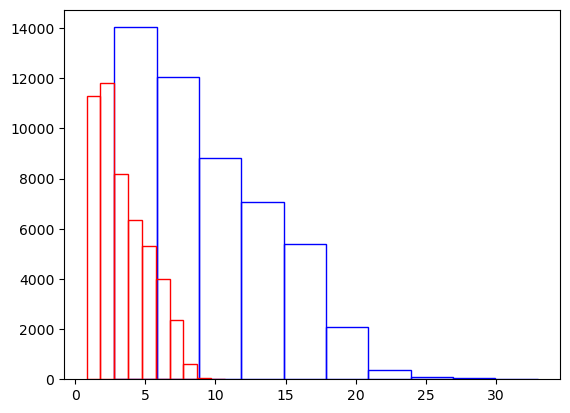

In [33]:
plt.hist(denoised['snr00'], fill=False, edgecolor='blue')
plt.hist(denoised['snr0'], fill=False, edgecolor='red')

# Train kernel ridge regression

In [34]:
from sklearn.kernel_ridge import KernelRidge

# Kernel Ridge Regression on PCA features
krr_model = KernelRidge(
    alpha=1e-5,
    kernel='rbf',
    gamma=1
)
krr_model.fit(X_train_pca, y_train_pca)

# Evaluate
y_pred_krr = krr_model.predict(X_test_pca)
mae_krr = mean_absolute_error(y_test_pca, y_pred_krr)
rmse_krr = mean_squared_error(y_test_pca, y_pred_krr, squared=False)
r2_krr = r2_score(y_test_pca, y_pred_krr)

print(f"KRR+PCA MAE : {mae_krr:.4f}")
print(f"KRR+PCA RMSE: {rmse_krr:.4f}")
print(f"KRR+PCA R^2 : {r2_krr:.4f}")

KRR+PCA MAE : 0.1537
KRR+PCA RMSE: 0.3809
KRR+PCA R^2 : 0.8902


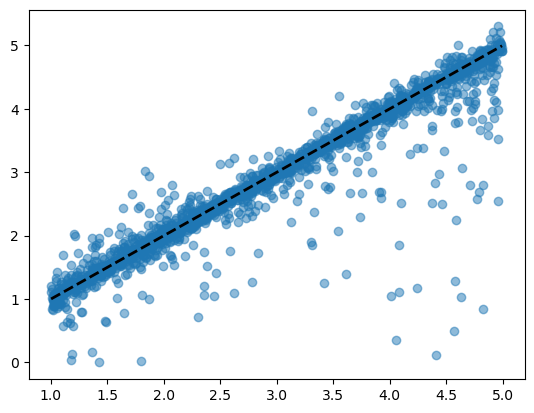

In [35]:
plt.plot(y_test_pca, y_pred_krr, 'o', alpha=0.5)
plt.plot([y_test_pca.min(), y_test_pca.max()], [y_test_pca.min(), y_test_pca.max()], 'k--', lw=2)

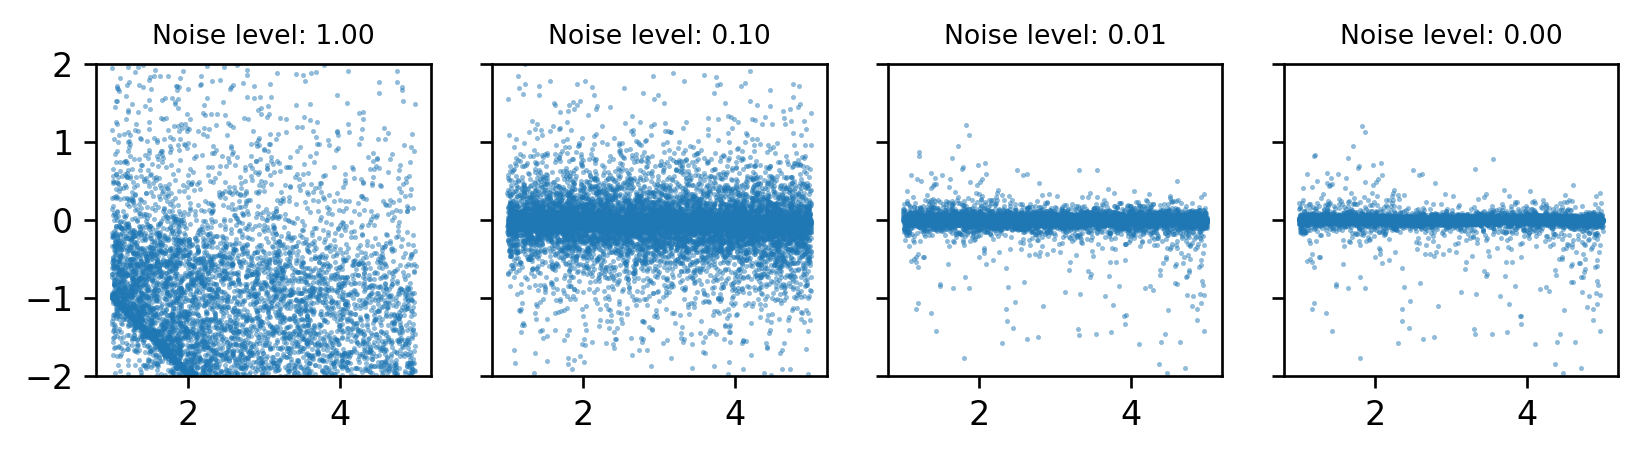

In [36]:
# Add all noise to the spectra

rng = np.random.default_rng(92)

fig, axes = plt.subplots(1, 4, figsize=(7, 2), dpi=240, sharex=True, sharey=True)

for i, (noise_level, ax) in enumerate(zip([1.0, 0.1, 0.01, 0.0], axes)):
    x_noisy = flux[:, wave_mask] + noise_level * rng.normal(loc=0.0, scale=err[:, wave_mask], size=flux[:, wave_mask].shape)

    # Predict log g using the trained Kernel Ridge Regression model on PCA features
    x_noisy_pca = pca.transform(x_noisy)
    y_pred_noisy = krr_model.predict(x_noisy_pca)

    ax.plot(y, y_pred_noisy - y, '.', ms=1, alpha=0.5)
    # ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)

    ax.set_title(f"Noise level: {noise_level:.2f}", fontsize=8)

    ax.set_ylim(-2, 2)

fig.tight_layout()

R^2 score for noisy predictions: -3.7327
R^2 score for denoised predictions: -0.3656


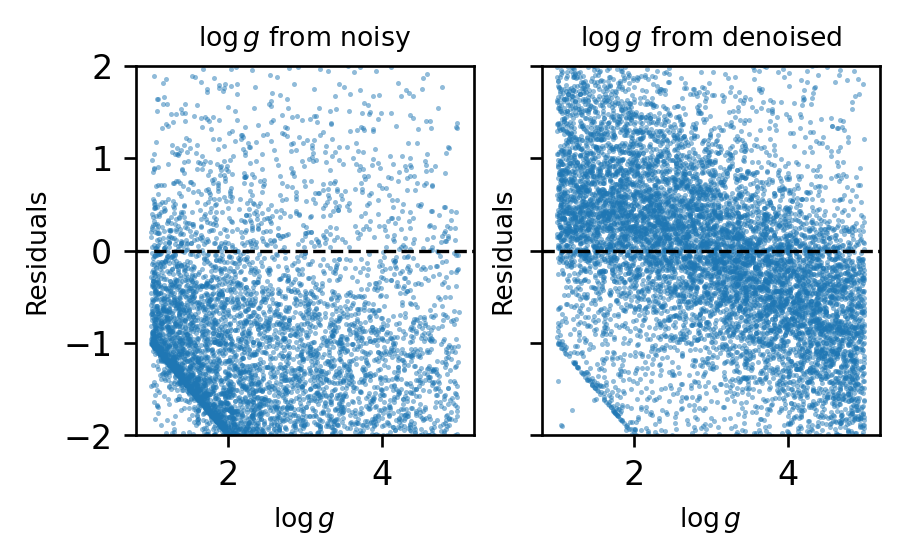

In [37]:
# Run through the noisy data and the denoised data

fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=240, sharex=True, sharey=True)

model_mask = denoised['snr00'] > 0
model_mask &= (denoised[DENOISED_PARAM] != np.round(denoised[DENOISED_PARAM], 1))

###### ####### #######

ax = axes[0]

x_noisy = denoised['noisy']

# Predict log g using the trained Kernel Ridge Regression model on PCA features
x_noisy_pca = pca.transform(x_noisy)
y_pred_noisy = krr_model.predict(x_noisy_pca)

ax.plot(denoised[DENOISED_PARAM][model_mask], y_pred_noisy[model_mask] - denoised[DENOISED_PARAM][model_mask], '.', ms=1, alpha=0.5)
# ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)

ax.set_title(f"{PARAM_LATEX} from noisy", fontsize=8)

###### ####### #######

ax = axes[1]

x_denoised = denoised['denoised']

# Predict log g using the trained Kernel Ridge Regression model on PCA features
x_denoised_pca = pca.transform(x_denoised)
y_pred_denoised = krr_model.predict(x_denoised_pca)

ax.plot(denoised[DENOISED_PARAM][model_mask], y_pred_denoised[model_mask] - denoised[DENOISED_PARAM][model_mask], '.', ms=1, alpha=0.5)
#ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)

ax.set_title(f"{PARAM_LATEX} from denoised", fontsize=8)

for ax in axes:
    ax.set_xlabel(f"{PARAM_LATEX}", fontsize=8)
    ax.set_ylabel(f"Residuals", fontsize=8)
    ax.axhline(0, color='k', lw=1, ls='--')
    ax.set_ylim(-2, 2)

# Calculate the R^2 score for both noisy and denoised predictions
R_2 = r2_score(denoised[DENOISED_PARAM][model_mask], y_pred_noisy[model_mask])
print(f"R^2 score for noisy predictions: {R_2:.4f}")
R_2_denoised = r2_score(denoised[DENOISED_PARAM][model_mask], y_pred_denoised[model_mask])
print(f"R^2 score for denoised predictions: {R_2_denoised:.4f}")